# How to use the code


## Define and initialize the simulation parameters

The simulation parameters are defined in the `simulation_params.py` file. The `Object`, `Setup` and `Camera` classes are used to define the parameters of the object, setup and camera respectively. The parameters of the object, setup and camera are passed as arguments to the respective classes. 

In [ ]:
from simulation_params_module import Object, Setup, Camera, Numerical
import matplotlib.pyplot as plt
import numpy as np
from utils import plot_mu

# Initializing the simulation parameters
setup = Setup(sigma_psf_x=1e-7, sigma_psf_y=1e-7)
obj = Object(xemit=np.array([0]), yemit=np.array([0]), zemit=np.array([0]))
cam = Camera(pixel_size_x=6.5e-6, pixel_size_y=6.5e-6, pixel_count=64, shutter_size_x=1)


INPUT WARNING (Setup class): sigma_psf_x is expected to be within (0, 1), but input value is 2. 
 For a fluorescence microscope, the standard deviation of the PSF is higher than expected
INPUT WARNING (Setup class): sigma_psf_y is expected to be within (0, 1), but input value is 2. 
 For a fluorescence microscope, the standard deviation of the PSF is higher than expected


## Instantiate the PSF model
The various PSF models are contained in classes in `psf_models.py`. These classes contain a shared method between all called `compute_psf()`. This method returns the PSF of the model in the form of a 3D numpy array.

In order to instantiate a PSF model of choice, the general `PSF` class in `psf_models.py` is called and the model type is passed as an argument. The PSF model is then instantiated along with the simulation parameters. In order to specifically obtain the PSF, the `compute_psf()` method of the PSF model is called.

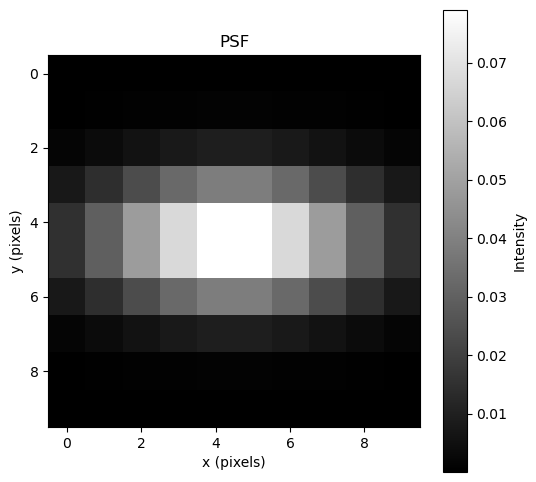

In [10]:
from PSF_module import PSF

# Instantiate the PSF model
psf_model = PSF(setup=setup, obj=obj, cam=cam, psf_model="gaussastigpsf")


# Compute the PSF
psf = psf_model.compute_psf()

# Plot the PSF
plot_mu(psf, title="PSF")

## Instantiate the illumination pattern

The illumination pattern is instantiated in the same way as the PSF model. The different types of patterns are contained as classes in the `illumination_pattern.py` file. These classes contain a shared method between all called `compute_illumination_pattern()`. This method returns the illumination pattern in the form of a  numpy array.

In order to instantiate the illumination pattern of choice, the `IlluminationPattern` class in `illumination_pattern.py` is called and the pattern type is passed as an argument. The illumination pattern is then instantiated along with the simulation parameters. In order to specifically obtain the illumination pattern, the `compute_illumination_pattern()` method of the illumination pattern is called.

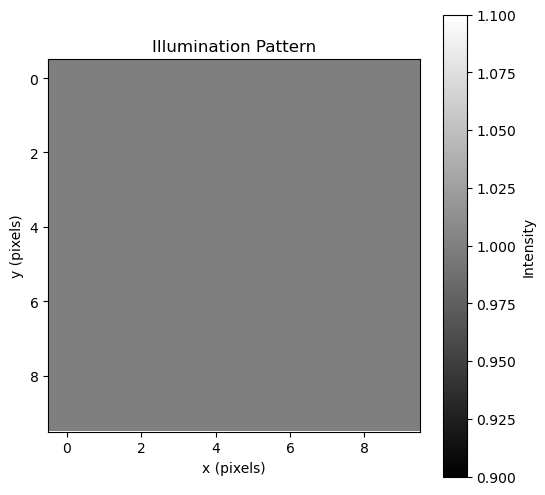

In [15]:
from illumination_pattern_module import IlluminationPattern

# Instantiate the type of illumination pattern
pattern_type = IlluminationPattern(setup=setup, obj=obj, cam=cam, pattern_type="widefield")

# Compute the illumination pattern
x,y, = cam.camera_grid

illumination_pattern = pattern_type.compute_illumination(x,y)

# Plot the illumination pattern
plot_mu(illumination_pattern, title="Illumination Pattern")

## Instantiate the patterned background term

No validation rules defined for Numerical
Using analytic solution.
Calculating analytic solution...


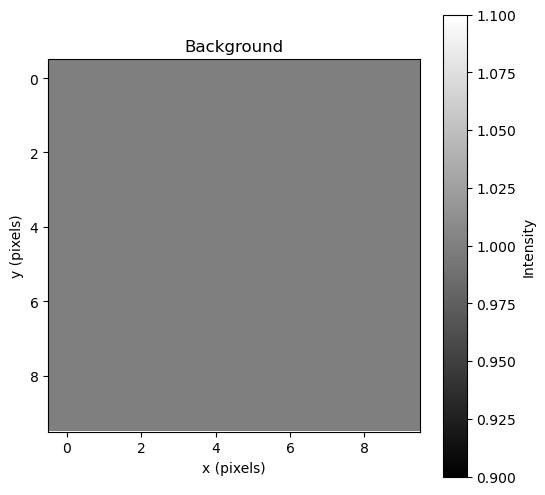

In [ ]:
from background_module import Background

# Instantiate and compute the background term
effective_background = Background(setup=setup, object=obj, camera=cam, 
                                  illumination_pattern=illumination_pattern, psf=psf,
                                  dimension=3, psf_model="gaussastigpsf", pattern_type="widefield").compute_background()

# Plot the background term
plot_mu(effective_background, title="Background")


## Simulate images using the ImageFormation class

The `ImageFormation` class in `image_formation.py` is used to combine the PSF, illumination pattern, pattern dependent background term, emitter intensity and expected background to form the expected photon count per pixel in order to simulate a noisy image. The class contains a method called `compute_image()` which returns the final image in the form of a numpy array. 


### Compute the expected photon count per pixel $\mu_{k}$

In order to compute the expected photon count per pixel, the `compute_photons_per_pixel()` method is called. The method takes the PSF, illumination pattern, pattern dependent background term, emitter intensity and expected background as arguments.

### Compute the partial derivatives w.r.t. the image parameters

The `ImageFromation` class contains multiple methods to obtain the partial derivatives of the expected photon count per pixel w.r.t. the image parameters. . Each of these methods returns the partial derivative in the form of a numpy array.

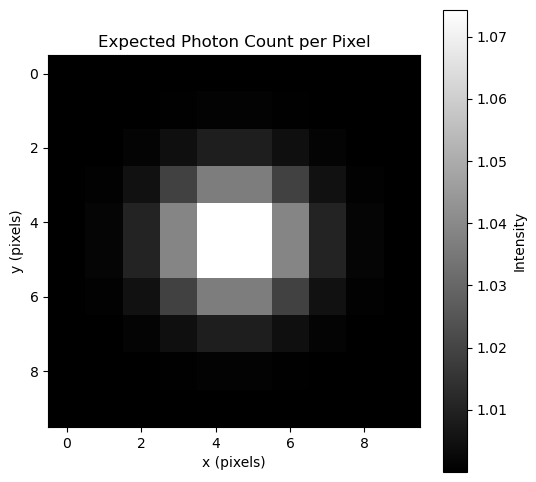

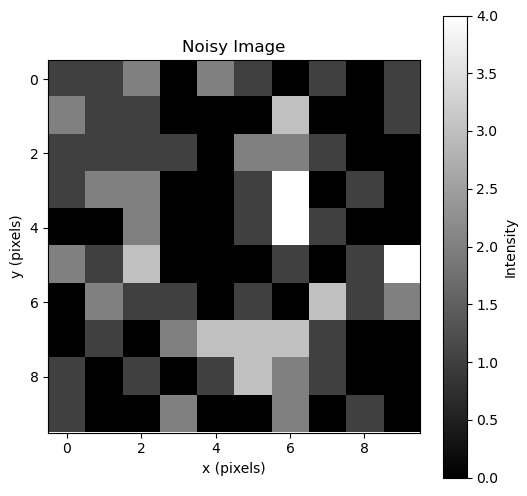

In [17]:
from image_formation_module import ImageFormation

# Instantiate the Image Formation class
image_formation= ImageFormation(setup=setup, obj=obj, cam=cam, psf=psf, illumination_pattern=illumination_pattern, effective_background=effective_background)

# Compute the expected photon count per pixel
mu, _ = image_formation.compute_photons_per_pixel()
noisy_mu = image_formation.compute_image(mu)
# Plot the expected photon count per pixel
plot_mu(mu, title="Expected Photon Count per Pixel", save_figure=False)

# Plot the noisy image 
plot_mu(noisy_mu, title="Noisy Image", save_figure=False)